# STAGE 1 (50 MÓN ĂN): SOTA FINE-TUNING COMPUTER VISION MODEL TRÊN GOOGLE COLAB

**Dự án:** AI NutriVision - Smart Food Recognition & Calorie Estimation System  
**Mô hình:** EfficientNet-B0 (SOTA Discriminative Fine-Tuning + TrivialAugmentWide + Resolution 288x288)  
**Quy mô:** **50 Món Ăn Phổ Biến Nhất** (Subset 50,000 hình ảnh từ Food-101 Dataset)  


In [ ]:
# [CELL 1] KIỂM TRA GPU VÀ CÀI ĐẶT THƯ VIỆN SOTA & ONNX SCRIPT
!nvidia-smi
!pip install -q onnx onnxscript onnxruntime

import os
import sys
import json
import time
import shutil
import urllib.request
import tarfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

Sun Aug  2 07:27:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# [CELL 2] CHỌN 50 MÓON ĂN PHỔ BIẾN & TẢI TẬP DỮ LIỆU FOOD-101 SUBSET (50,000 Ảnh)
SELECTED_CLASSES = [
    'apple_pie', 'baby_back_ribs', 'baklava', 'beignets', 'bibimbap',
    'bread_pudding', 'caesar_salad', 'caprese_salad', 'carrot_cake', 'cheesecake',
    'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'churros',
    'club_sandwich', 'cup_cakes', 'donuts', 'dumplings', 'eggs_benedict',
    'falafel', 'filet_mignon', 'french_fries', 'fried_rice', 'garlic_bread',
    'greek_salad', 'gyoza', 'hamburger', 'hot_and_sour_soup', 'hot_dog',
    'ice_cream', 'lasagna', 'macaroni_and_cheese', 'macarons', 'nachos',
    'omelette', 'pad_thai', 'pancakes', 'pho', 'pizza',
    'ramen', 'ravioli', 'risotto', 'samosa', 'spaghetti_bolognese',
    'spring_rolls', 'steak', 'sushi', 'tacos', 'waffles'
]

DATASET_URL = "http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz"
TAR_PATH = "food-101.tar.gz"
EXTRACT_DIR = "./food-101-raw"
SUBSET_DIR = "./food-101-subset50"

if not os.path.exists(SUBSET_DIR):
    if not os.path.exists(TAR_PATH):
        print("Dang tai Food-101 dataset (~5GB)... Vui long cho 2-3 phut.")
        urllib.request.urlretrieve(DATASET_URL, TAR_PATH)
        print("Tai dataset thanh cong!")

    print("Dang giai nen du lieu...")
    with tarfile.open(TAR_PATH, "r:gz") as tar:
        tar.extractall(path=EXTRACT_DIR)
    print("Giai nen hoan tat!")

    print(f"Dang trich xuat subset 50 lop mon an vao {SUBSET_DIR}...")
    raw_images_dir = os.path.join(EXTRACT_DIR, "food-101", "images")

    for split in ['train', 'val', 'test']:
        for cls in SELECTED_CLASSES:
            src_cls_dir = os.path.join(raw_images_dir, cls)
            dst_cls_dir = os.path.join(SUBSET_DIR, split, cls)
            os.makedirs(dst_cls_dir, exist_ok=True)

            if os.path.exists(src_cls_dir):
                all_files = sorted(os.listdir(src_cls_dir))
                if split == 'train':
                    selected_files = all_files[:750]
                elif split == 'val':
                    selected_files = all_files[750:900]
                else:
                    selected_files = all_files[900:1000]

                for f in selected_files:
                    shutil.copy(os.path.join(src_cls_dir, f), os.path.join(dst_cls_dir, f))

    print(f"Da chuan bi xong subset dataset voi 50 lop mon an! Total classes: {len(SELECTED_CLASSES)}")
else:
    print(f"Thu muc dataset subset 50 mon da ton tai tai {SUBSET_DIR}.")

Dang tai Food-101 dataset (~5GB)... Vui long cho 2-3 phut.
Tai dataset thanh cong!
Dang giai nen du lieu...


/tmp/ipykernel_908/2129110652.py:28: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=EXTRACT_DIR)


Giai nen hoan tat!
Dang trich xuat subset 50 lop mon an vao ./food-101-subset50...
Da chuan bi xong subset dataset voi 50 lop mon an! Total classes: 50


In [ ]:
# [CELL 3] BẢNG TRA CỨU DINH DƯỠNG (CALORIE MAP FOR 50 FOOD CLASSES)
CALORIE_MAP_50 = {
    "apple_pie": {"name": "Bánh Táo Apple Pie", "category": "Tráng Miệng", "calories": 320, "protein_g": 3.0, "carbs_g": 45.0, "fat_g": 14.0},
    "baby_back_ribs": {"name": "Sườn Nướng BBQ", "category": "Món Nướng", "calories": 580, "protein_g": 45.0, "carbs_g": 12.0, "fat_g": 38.0},
    "baklava": {"name": "Bánh Hạt Baklava", "category": "Tráng Miệng", "calories": 330, "protein_g": 5.0, "carbs_g": 38.0, "fat_g": 18.0},
    "beignets": {"name": "Bánh Rán Beignets", "category": "Tráng Miệng", "calories": 290, "protein_g": 4.0, "carbs_g": 35.0, "fat_g": 15.0},
    "bibimbap": {"name": "Cơm Trộn Hàn Quốc", "category": "Cơm Món", "calories": 490, "protein_g": 21.0, "carbs_g": 68.0, "fat_g": 14.0},
    "bread_pudding": {"name": "Pudding Bánh Mì", "category": "Tráng Miệng", "calories": 270, "protein_g": 6.0, "carbs_g": 42.0, "fat_g": 9.0},
    "caesar_salad": {"name": "Salad Caesar Gà", "category": "Salad", "calories": 220, "protein_g": 15.0, "carbs_g": 10.0, "fat_g": 14.0},
    "caprese_salad": {"name": "Salad Caprese Ý", "category": "Salad", "calories": 190, "protein_g": 10.0, "carbs_g": 6.0, "fat_g": 14.0},
    "carrot_cake": {"name": "Bánh Cà Rốt", "category": "Tráng Miệng", "calories": 340, "protein_g": 4.0, "carbs_g": 48.0, "fat_g": 16.0},
    "cheesecake": {"name": "Bánh Phô Mai Cheesecake", "category": "Tráng Miệng", "calories": 400, "protein_g": 7.0, "carbs_g": 32.0, "fat_g": 28.0},
    "chicken_curry": {"name": "Cà Rê Gà Ấn Độ", "category": "Món Nước", "calories": 410, "protein_g": 28.0, "carbs_g": 22.0, "fat_g": 24.0},
    "chicken_quesadilla": {"name": "Bánh Quesadilla Gà", "category": "Fast Food", "calories": 510, "protein_g": 32.0, "carbs_g": 40.0, "fat_g": 24.0},
    "chicken_wings": {"name": "Cánh Gà Chiên Chiên BBQ", "category": "Fast Food", "calories": 430, "protein_g": 30.0, "carbs_g": 15.0, "fat_g": 28.0},
    "chocolate_cake": {"name": "Bánh Socola Chocolate Cake", "category": "Tráng Miệng", "calories": 370, "protein_g": 5.0, "carbs_g": 52.0, "fat_g": 17.0},
    "churros": {"name": "Bánh Quẩy Churros Tây Ban Nha", "category": "Tráng Miệng", "calories": 280, "protein_g": 3.5, "carbs_g": 36.0, "fat_g": 14.0},
    "club_sandwich": {"name": "Bánh Mì Kẹp Club Sandwich", "category": "Fast Food", "calories": 420, "protein_g": 24.0, "carbs_g": 41.0, "fat_g": 18.0},
    "cup_cakes": {"name": "Bánh Cupcake Kem", "category": "Tráng Miệng", "calories": 240, "protein_g": 2.5, "carbs_g": 33.0, "fat_g": 11.0},
    "donuts": {"name": "Bánh Donut Socola", "category": "Tráng Miệng", "calories": 270, "protein_g": 3.5, "carbs_g": 31.0, "fat_g": 15.0},
    "dumplings": {"name": "Há Cảo Hấp", "category": "Món Hấp", "calories": 240, "protein_g": 12.0, "carbs_g": 32.0, "fat_g": 7.0},
    "eggs_benedict": {"name": "Trứng Chần Eggs Benedict", "category": "Điểm Tâm", "calories": 360, "protein_g": 18.0, "carbs_g": 24.0, "fat_g": 22.0},
    "falafel": {"name": "Chả Đậu Falafel", "category": "Ăn Chay", "calories": 330, "protein_g": 13.0, "carbs_g": 32.0, "fat_g": 17.0},
    "filet_mignon": {"name": "Bít Tết Filet Mignon", "category": "Món Nướng", "calories": 460, "protein_g": 44.0, "carbs_g": 1.0, "fat_g": 30.0},
    "french_fries": {"name": "Khoai Tây Chiên", "category": "Fast Food", "calories": 365, "protein_g": 4.0, "carbs_g": 48.0, "fat_g": 17.0},
    "fried_rice": {"name": "Cơm Chiên Dương Châu", "category": "Cơm Món", "calories": 420, "protein_g": 14.0, "carbs_g": 62.0, "fat_g": 14.0},
    "garlic_bread": {"name": "Bánh Mì Bơ Tỏi", "category": "Khai Vị", "calories": 210, "protein_g": 5.0, "carbs_g": 26.0, "fat_g": 10.0},
    "greek_salad": {"name": "Salad Hy Lạp Feta", "category": "Salad", "calories": 180, "protein_g": 6.0, "carbs_g": 8.0, "fat_g": 14.0},
    "gyoza": {"name": "Bánh Chẻo Gyoza Nhật", "category": "Món Chiên", "calories": 260, "protein_g": 11.0, "carbs_g": 28.0, "fat_g": 11.0},
    "hamburger": {"name": "Beef Hamburger", "category": "Fast Food", "calories": 295, "protein_g": 17.0, "carbs_g": 30.0, "fat_g": 13.0},
    "hot_and_sour_soup": {"name": "Súp Chua Cay Tứ Xuyên", "category": "Súp", "calories": 160, "protein_g": 9.0, "carbs_g": 14.0, "fat_g": 7.0},
    "hot_dog": {"name": "Bánh Mì Xúc Xích Hot Dog", "category": "Fast Food", "calories": 310, "protein_g": 12.0, "carbs_g": 24.0, "fat_g": 18.0},
    "ice_cream": {"name": "Kem Trái Cây", "category": "Tráng Miệng", "calories": 210, "protein_g": 4.0, "carbs_g": 28.0, "fat_g": 10.0},
    "lasagna": {"name": "Lasagna Ý Đút Lò", "category": "Món Ý", "calories": 410, "protein_g": 21.0, "carbs_g": 35.0, "fat_g": 20.0},
    "macaroni_and_cheese": {"name": "Nui Phô Mai Mac & Cheese", "category": "Món Ý", "calories": 450, "protein_g": 16.0, "carbs_g": 46.0, "fat_g": 22.0},
    "macarons": {"name": "Bánh Macaron Pháp", "category": "Tráng Miệng", "calories": 160, "protein_g": 3.0, "carbs_g": 22.0, "fat_g": 7.0},
    "nachos": {"name": "Bánh Bắp Phô Mai Nachos", "category": "Snack", "calories": 480, "protein_g": 12.0, "carbs_g": 55.0, "fat_g": 24.0},
    "omelette": {"name": "Trứng Chiên Omelette", "category": "Điểm Tâm", "calories": 240, "protein_g": 14.0, "carbs_g": 2.0, "fat_g": 19.0},
    "pad_thai": {"name": "Pad Thai Xào Tôm", "category": "Món Xào", "calories": 450, "protein_g": 20.0, "carbs_g": 60.0, "fat_g": 15.0},
    "pancakes": {"name": "Bánh Kếp Pancakes Bơ Mật Ong", "category": "Điểm Tâm", "calories": 350, "protein_g": 8.0, "carbs_g": 58.0, "fat_g": 10.0},
    "pho": {"name": "Phở Bò Việt Nam", "category": "Món Nước", "calories": 380, "protein_g": 22.0, "carbs_g": 54.0, "fat_g": 8.5},
    "pizza": {"name": "Pepperoni Pizza", "category": "Fast Food", "calories": 285, "protein_g": 12.0, "carbs_g": 34.0, "fat_g": 11.0},
    "ramen": {"name": "Tonkotsu Ramen", "category": "Món Nước", "calories": 520, "protein_g": 25.0, "carbs_g": 65.0, "fat_g": 18.0},
    "ravioli": {"name": "Bánh Mì Ý Ravioli Nhân Thịt", "category": "Món Ý", "calories": 380, "protein_g": 18.0, "carbs_g": 42.0, "fat_g": 15.0},
    "risotto": {"name": "Cơm Ý Risotto Nấm Phô Mai", "category": "Món Ý", "calories": 420, "protein_g": 11.0, "carbs_g": 54.0, "fat_g": 18.0},
    "samosa": {"name": "Bánh Tam Giác Samosa Ấn Độ", "category": "Chiên Rán", "calories": 260, "protein_g": 5.0, "carbs_g": 32.0, "fat_g": 12.0},
    "spaghetti_bolognese": {"name": "Mì Ý Sốt Bò Băm Spaghetti", "category": "Món Ý", "calories": 440, "protein_g": 22.0, "carbs_g": 58.0, "fat_g": 13.0},
    "spring_rolls": {"name": "Gỏi Cuốn Tôm Thịt", "category": "Món Cuốn", "calories": 180, "protein_g": 11.0, "carbs_g": 24.0, "fat_g": 3.5},
    "steak": {"name": "Bít Tết Bò BBQ", "category": "Món Nướng", "calories": 480, "protein_g": 42.0, "carbs_g": 2.0, "fat_g": 32.0},
    "sushi": {"name": "Salmon Sushi Roll", "category": "Hải Sản", "calories": 310, "protein_g": 18.0, "carbs_g": 42.0, "fat_g": 5.2},
    "tacos": {"name": "Tacos Bò Mexico", "category": "Fast Food", "calories": 310, "protein_g": 16.0, "carbs_g": 26.0, "fat_g": 15.0},
    "waffles": {"name": "Bánh Tổ Ong Waffles", "category": "Tráng Miệng", "calories": 310, "protein_g": 6.0, "carbs_g": 45.0, "fat_g": 11.0}
}

with open("calorie_map.json", "w", encoding="utf-8") as f:
    json.dump(CALORIE_MAP_50, f, ensure_ascii=False, indent=2)
print(f"Da luu calorie_map.json cho {len(CALORIE_MAP_50)} mon an thanh cong!")

Da luu calorie_map.json cho 50 mon an thanh cong!


In [ ]:
# [CELL 4 - NÂNG CẤP SOTA 50 LỚP] HIGH-RESOLUTION (288x288) & TRIVIALAUGMENTWIDE AUGMENTATION
BATCH_SIZE = 32
IMAGE_SIZE = (288, 288)

train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomResizedCrop(288, scale=(0.75, 1.0)),
    transforms.TrivialAugmentWide(),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(288),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(SUBSET_DIR, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(SUBSET_DIR, "val"), transform=val_test_transform)
test_dataset = datasets.ImageFolder(os.path.join(SUBSET_DIR, "test"), transform=val_test_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

classes = train_dataset.classes
print(f"Da cai dat High-Res (288x288) & TrivialAugmentWide cho 50 Lop Mon An:")
print(f"  - Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"  - Danh sach classes: {classes[:10]} ... va {len(classes)-10} mon nua.")

Da cai dat High-Res (288x288) & TrivialAugmentWide cho 50 Lop Mon An:
  - Train: 37500 | Val: 7500 | Test: 5000
  - Danh sach classes: ['apple_pie', 'baby_back_ribs', 'baklava', 'beignets', 'bibimbap', 'bread_pudding', 'caesar_salad', 'caprese_salad', 'carrot_cake', 'cheesecake'] ... va 40 mon nua.


In [ ]:
# [CELL 5 - NÂNG CẤP SOTA 50 LỚP] EFFICIENTNET-B0 VỚI DISCRIMINATIVE LEARNING RATES
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiet bi su dung: {device}")

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_features, len(classes))
)
model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
print(f"Da cau hinh mo hinh EfficientNet-B0 cho {len(classes)} lop mon an voi Label Smoothing Loss (0.1).")

Thiet bi su dung: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 170MB/s]


Da cau hinh mo hinh EfficientNet-B0 cho 50 lop mon an voi Label Smoothing Loss (0.1).


In [ ]:
# [CELL 6 - NÂNG CẤP SOTA 50 LỚP] VÒNG LẶP HUẤN LUYỆN 2 GIAI ĐOẠN (TWO-STAGE FINE-TUNING)
print("GIAI DOAN 1: Warmup Classifier Head (3 Epochs - Freeze Backbone)")
for param in model.features.parameters():
    param.requires_grad = False

optimizer = optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-2)

for epoch in range(1, 4):
    model.train()
    r_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        outs = model(imgs)
        loss = criterion(outs, lbls)
        loss.backward()
        optimizer.step()
        r_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outs, 1)
        correct += torch.sum(preds == lbls.data).item()
        total += lbls.size(0)
    print(f"  [Phase 1 - Epoch {epoch}/3] Train Loss: {r_loss/total:.4f} | Train Acc: {(correct/total)*100:.2f}%")

print("\nGIAI DOAN 2: Mo khoa toan bo Backbone (Full Unfreeze 7 Epochs)")
for param in model.features.parameters():
    param.requires_grad = True

optimizer = optim.AdamW([
    {'params': model.features.parameters(), 'lr': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
], weight_decay=1e-2)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=7)

best_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, 8):
    start_time = time.time()
    model.train()
    r_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        outs = model(imgs)
        loss = criterion(outs, lbls)
        loss.backward()
        optimizer.step()
        r_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outs, 1)
        correct += torch.sum(preds == lbls.data).item()
        total += lbls.size(0)

    scheduler.step()
    t_loss = r_loss / total
    t_acc = (correct / total) * 100

    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outs = model(imgs)
            loss = criterion(outs, lbls)
            v_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outs, 1)
            v_correct += torch.sum(preds == lbls.data).item()
            v_total += lbls.size(0)

    val_loss = v_loss / v_total
    val_acc = (v_correct / v_total) * 100
    elapsed = time.time() - start_time

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"  [Phase 2 - Epoch {epoch:02d}/07] Train Loss: {t_loss:.4f} | Train Acc: {t_acc:6.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:6.2f}% | Time: {elapsed:.1f}s")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'classes': classes,
            'val_acc': val_acc
        }, "best_food_model.pth")
        print(f"    Best Checkpoint Saved! Val Acc = {val_acc:.2f}%")

print("=" * 75)
print(f"KET QUA DAT DUOC SAU FINE-TUNING 2 GIAI DOAN (50 MON AN): Validation Accuracy = {best_acc:.2f}%")

GIAI DOAN 1: Warmup Classifier Head (3 Epochs - Freeze Backbone)
  [Phase 1 - Epoch 1/3] Train Loss: 2.6069 | Train Acc: 43.53%
  [Phase 1 - Epoch 2/3] Train Loss: 2.2691 | Train Acc: 51.70%
  [Phase 1 - Epoch 3/3] Train Loss: 2.2236 | Train Acc: 52.98%

GIAI DOAN 2: Mo khoa toan bo Backbone (Full Unfreeze 7 Epochs)
  [Phase 2 - Epoch 01/07] Train Loss: 1.7842 | Train Acc:  67.37% | Val Loss: 1.3957 | Val Acc:  80.53% | Time: 411.2s
    Best Checkpoint Saved! Val Acc = 80.53%
  [Phase 2 - Epoch 02/07] Train Loss: 1.5081 | Train Acc:  76.44% | Val Loss: 1.2955 | Val Acc:  83.79% | Time: 410.6s
    Best Checkpoint Saved! Val Acc = 83.79%
  [Phase 2 - Epoch 03/07] Train Loss: 1.3882 | Train Acc:  80.44% | Val Loss: 1.2534 | Val Acc:  84.61% | Time: 411.7s
    Best Checkpoint Saved! Val Acc = 84.61%
  [Phase 2 - Epoch 04/07] Train Loss: 1.3015 | Train Acc:  83.46% | Val Loss: 1.2202 | Val Acc:  85.52% | Time: 403.2s
    Best Checkpoint Saved! Val Acc = 85.52%
  [Phase 2 - Epoch 05/07] Trai

OVERALL TEST TOP-1 ACCURACY (50 MON AN): 85.62%

BAO CAO PHAN LOAI CHI TIET (CLASSIFICATION REPORT FOR 50 CLASSES):
                     precision    recall  f1-score   support

          apple_pie       0.71      0.71      0.71       100
     baby_back_ribs       0.89      0.85      0.87       100
            baklava       0.88      0.92      0.90       100
           beignets       0.86      0.87      0.87       100
           bibimbap       0.91      0.94      0.93       100
      bread_pudding       0.64      0.74      0.69       100
       caesar_salad       0.86      0.89      0.87       100
      caprese_salad       0.90      0.91      0.91       100
        carrot_cake       0.89      0.79      0.84       100
         cheesecake       0.82      0.81      0.81       100
      chicken_curry       0.81      0.76      0.78       100
 chicken_quesadilla       0.85      0.77      0.81       100
      chicken_wings       0.88      0.94      0.91       100
     chocolate_cake       0.7

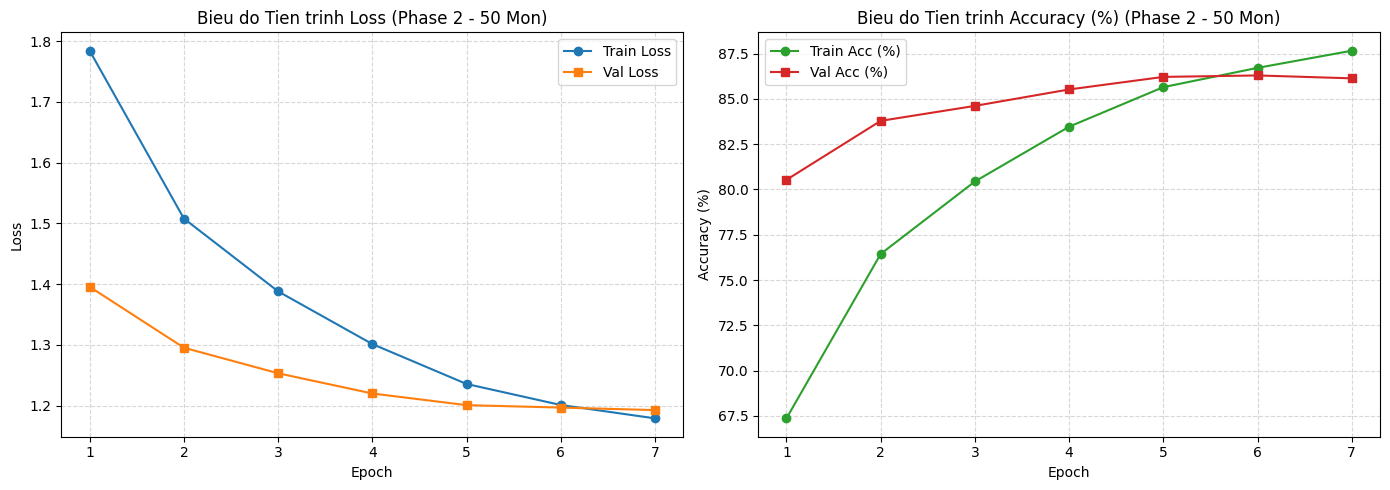

In [ ]:
# [CELL 7 - CHUẨN HOÁ 50 LỚP] ĐÁNH GIÁ TRÊN TẬP TEST ĐỘC LẬP (5,000 Ảnh Test)
eval_model = models.efficientnet_b0(weights=None)
num_features = eval_model.classifier[1].in_features
eval_model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_features, len(classes))
)

checkpoint = torch.load("best_food_model.pth", map_location=device)
eval_model.load_state_dict(checkpoint['model_state_dict'])
eval_model.to(device)
eval_model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = eval_model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

test_acc = np.mean(np.array(y_true) == np.array(y_pred)) * 100
print("=" * 75)
print(f"OVERALL TEST TOP-1 ACCURACY (50 MON AN): {test_acc:.2f}%")
print("=" * 75)
print("\nBAO CAO PHAN LOAI CHI TIET (CLASSIFICATION REPORT FOR 50 CLASSES):")
print(classification_report(y_true, y_pred, target_names=classes))

if 'history' in globals() and len(history['train_loss']) > 0:
    plt.figure(figsize=(14, 5))
    epochs_range = range(1, len(history['train_loss']) + 1)

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='#1f77b4')
    plt.plot(epochs_range, history['val_loss'], 's-', label='Val Loss', color='#ff7f0e')
    plt.title('Bieu do Tien trinh Loss (Phase 2 - 50 Mon)', fontsize=12)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], 'o-', label='Train Acc (%)', color='#2ca02c')
    plt.plot(epochs_range, history['val_acc'], 's-', label='Val Acc (%)', color='#d62728')
    plt.title('Bieu do Tien trinh Accuracy (%) (Phase 2 - 50 Mon)', fontsize=12)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
# Cài đặt tự động các thư viện ONNX thiếu
!pip install -q onnx onnxscript onnxruntime

import torch
import torchvision.models as models
import os

print("1. Đang khởi tạo mô hình EfficientNet-B0 cho 50 món...")
model = models.efficientnet_b0(weights=None)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = torch.nn.Linear(num_ftrs, 50)

print("2. Đang nạp trọng số từ file best_food_model.pth...")
checkpoint = torch.load('best_food_model.pth', map_location='cpu')

# Bóc tách lấy đúng phần trọng số model_state_dict
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
else:
    state_dict = checkpoint

model.load_state_dict(state_dict)
model.eval()

print("3. Đang xuất mô hình sang định dạng ONNX (Classic Exporter: dynamo=False)...")
dummy_input = torch.randn(1, 3, 288, 288)

torch.onnx.export(
    model,
    dummy_input,
    "food_model.onnx",
    export_params=True,        # Đóng gói trọn vẹn 100% trọng số
    opset_version=18,          # Chuẩn Opset 18
    dynamo=False,              # CHÍNH LÀ ĐÂY: Tắt Dynamo để ép nhúng 15.5MB weights vào file!
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)

# Kiểm tra dung lượng file ONNX sau khi export
size_mb = os.path.getsize('food_model.onnx') / (1024 * 1024)
print(f"\n✅ EXPORT THÀNH CÔNG RỰC RỠ!")
print(f"Dung lượng file food_model.onnx chuẩn: {size_mb:.2f} MB")

1. Đang khởi tạo mô hình EfficientNet-B0 cho 50 món...
2. Đang nạp trọng số từ file best_food_model.pth...
3. Đang xuất mô hình sang định dạng ONNX (Classic Exporter: dynamo=False)...


/tmp/ipykernel_1045/1703419821.py:28: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(



✅ EXPORT THÀNH CÔNG RỰC RỠ!
Dung lượng file food_model.onnx chuẩn: 15.52 MB


In [ ]:
# [CELL 9] SAO LƯU ARTIFACTS VÀO GOOGLE DRIVE
try:
    from google.colab import drive
    drive.mount('/content/drive')
    save_dir = "/content/drive/MyDrive/AWS_NutriVision_Model_50Classes"
    os.makedirs(save_dir, exist_ok=True)
    shutil.copy("best_food_model.pth", os.path.join(save_dir, "best_food_model.pth"))
    shutil.copy("food_model.onnx", os.path.join(save_dir, "food_model.onnx"))
    shutil.copy("calorie_map.json", os.path.join(save_dir, "calorie_map.json"))
    print(f"Da sao luu toan bo artifacts 50 lop vao Google Drive: {save_dir}")
except Exception as e:
    print(f"Vui long tai tep food_model.onnx thu cong.")

Vui long tai tep food_model.onnx thu cong.
